In [71]:
import pandas as pd 
import matplotlib.pyplot as plt

In [72]:
fake_df =pd.read_csv("Dataset/Fake.csv")
true_df =pd.read_csv("Dataset/True.csv")

In [73]:
fake_df.head()



,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [74]:
fake_df.shape
true_df.shape[0]


21417

In [75]:
fake_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB


In [76]:
fake_df.columns

Index(['title', 'text', 'subject', 'date'], dtype='str')

In [77]:
fake_df.dtypes

title      str
text       str
subject    str
date       str
dtype: object

In [78]:
fake_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [79]:
fake_df.sample(1)

,title,text,subject,date
541,Former Business Partner Predicts Prison For T...,"Donald Trump is going to jail, and his former ...",News,"August 17, 2017"


In [80]:
fake_articles = fake_df.shape[0]
ture_articles = true_df.shape[0]


In [81]:
print("fake articles are : ",fake_articles)
print("true articles are : ",true_df.shape[0])
total_articles= fake_df.shape[0]+true_df.shape[0]
print("total articles are:",total_articles)

fake articles are :  23481
true articles are :  21417
total articles are: 44898


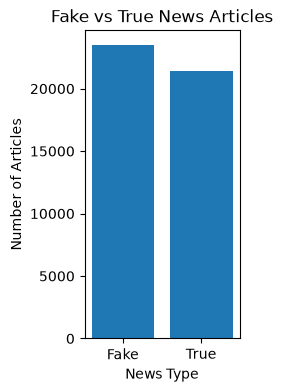

In [82]:
labels = ['Fake','True']
values = [fake_articles,ture_articles]
plt.figure(figsize=(2,4))
plt.bar(labels,values)
plt.title("Fake vs True News Articles")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")
plt.show()




In [83]:

print("Duplicate articles in fake news dataset are: ",fake_df.duplicated().sum())
print("Duplicate articles in true news dataset are: ",true_df.duplicated().sum())

Duplicate articles in fake news dataset are:  3
Duplicate articles in true news dataset are:  206


In [84]:
fake_df["subject"].value_counts()

subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

<BarContainer object of 6 artists>

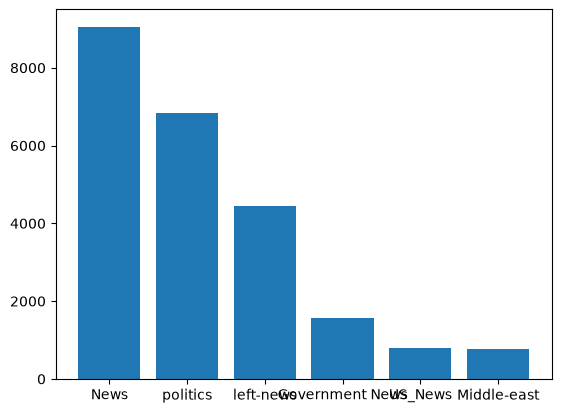

In [85]:
labels = fake_df["subject"].value_counts().index
values = fake_df["subject"].value_counts().values
plt.bar(labels,values)

In [86]:
print(fake_df["date"].head())
print(fake_df["date"].dtype)
print(fake_df["date"].isnull().sum())

0    December 31, 2017
1    December 31, 2017
2    December 30, 2017
3    December 29, 2017
4    December 25, 2017
Name: date, dtype: str
str
0


In [87]:
fake_df[fake_df["date"].str.contains("-")]["date"].head(10)


9050    19-Feb-18
9051    19-Feb-18
9052    19-Feb-18
9053    18-Feb-18
9054    18-Feb-18
9055    18-Feb-18
9056    18-Feb-18
9057    18-Feb-18
9058    18-Feb-18
9059    18-Feb-18
Name: date, dtype: str

In [88]:
fake_df["date"].unique()[:20]

<StringArray>
['December 31, 2017', 'December 30, 2017', 'December 29, 2017',
 'December 25, 2017', 'December 23, 2017', 'December 22, 2017',
 'December 21, 2017', 'December 20, 2017', 'December 19, 2017',
 'December 17, 2017', 'December 16, 2017', 'December 13, 2017',
 'December 12, 2017', 'December 11, 2017', 'December 10, 2017',
  'December 9, 2017',  'December 7, 2017',  'December 6, 2017',
  'December 5, 2017',  'December 4, 2017']
Length: 20, dtype: str

In [89]:
fake_df["date"].str.len().value_counts()

date
12     10240
11      4022
16      2218
13      1843
17      1797
14      1725
15      1093
18       498
9         35
74         3
66         3
145        1
88         1
149        1
120        1
Name: count, dtype: int64

In [90]:
fake_df[fake_df["date"].str.len() > 30]["date"]
#idk whats going on with these dates, they are not in a proper format. I will remove them from the dataset.
#or im thinking to drop these so that we can convert the rest of the dates into datetime format.
# lets focus on something else for now and come back to this later. I will drop these dates for now.

9358     https://100percentfedup.com/served-roy-moore-v...
15507    https://100percentfedup.com/video-hillary-aske...
15508    https://100percentfedup.com/12-yr-old-black-co...
15839    https://fedup.wpengine.com/wp-content/uploads/...
15840    https://fedup.wpengine.com/wp-content/uploads/...
17432    https://fedup.wpengine.com/wp-content/uploads/...
17433    https://fedup.wpengine.com/wp-content/uploads/...
18933    MSNBC HOST Rudely Assumes Steel Worker Would N...
21869    https://fedup.wpengine.com/wp-content/uploads/...
21870    https://fedup.wpengine.com/wp-content/uploads/...
Name: date, dtype: str

In [91]:
fake_df['label'] = 0
true_df['label'] = 1


In [92]:
df = pd.concat([fake_df,true_df],ignore_index=True)


In [93]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [94]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [95]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

#Real ML starts here hahaha 
#we will use re library to clear things like capitals symbols emojis extra spaces and so on to make it AI Redable 

In [96]:
import re 

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z A-Z\s]', '', text)  #they said this is regex rn idk whats regex is so lets dont bum our head a this rn 
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


In [97]:
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(3)

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",st century wire says ben stein reputable profe...
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters us president donald trump r...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...


Splitting the dataset before TF-IDF dk what that is lets find out 


In [98]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [99]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

35918
8980
35918
8980


TF -IDF(TERM FREQUENCY - INVERSE DOCUMENT FREQUENCY) -: With this it ill convert normal text into vector of numbers that a machine learning model can understand.



In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [101]:
vectorizer = TfidfVectorizer(
    max_features =5000,
    stop_words="english"
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [102]:
print(X_train_tfidf.shape)

(35918, 5000)


In [103]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()


In [105]:
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

training data is used to teach the model.Test dta is kept aside and is only used to check how well the model learned on data it has never seen before. 

In [106]:
y_pred = model.predict(X_test_tfidf)



#Take the 8,980 test articles
 #       ↓
#Convert each article into a prediction
#        ↓
#Store every prediction inside a variable called y_pred



print(y_pred[:20])

[0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 1]


HAT ACTUALLY HAPPENED DURING predict()

Article 1
        ↓
Calculate probability
        ↓
98% Real
        ↓
Return 1

-------------------

Article 2
        ↓
Calculate probability
        ↓
7% Real
        ↓
Return 0

-------------------

Article 3
        ↓
83% Real
        ↓
Return 1


it repeated that thousands of times in a fraction of a second.


In [107]:
#Next step is simply comparing them 
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
print(f"Accuracy: {accuracy * 100:.2f}%")

0.9867483296213808
Accuracy: 98.67%


In [108]:
# BASIC TERMNOLOGY


pi = 3.1415926535
print(pi)
print(f"{pi:.3f}") 



#           The pieces mean:

#       : → "Start formatting"
#       .2 → "Keep 2 digits after the decimal"
#       f → "Display it as a floating-point number" 

3.1415926535
3.142
